# 02 â€” Exploratory Analysis
Target distributions, correlations of prevN_* features, class balance.

In [1]:

import sys, os
from pathlib import Path
root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

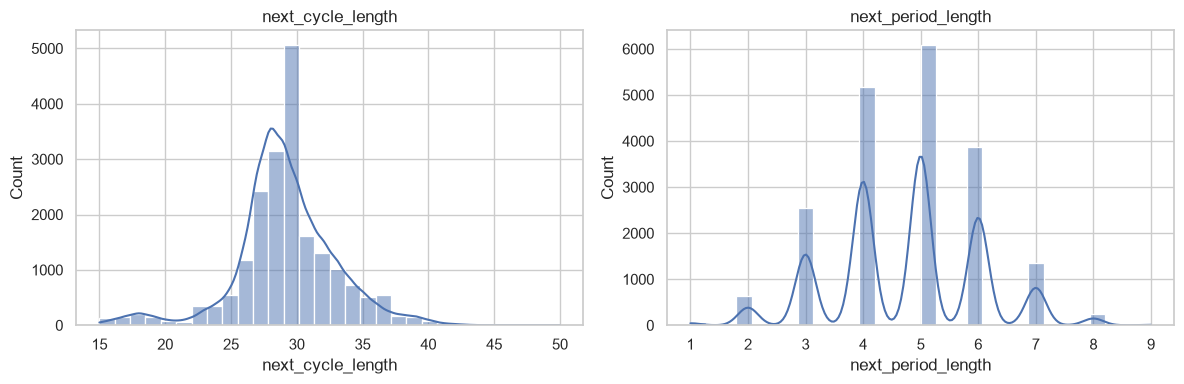

       next_cycle_length  next_period_length
count          20000.000           20000.000
mean              29.136               4.745
std                3.864               1.277
min               15.000               1.000
25%               27.000               4.000
50%               29.000               5.000
75%               31.000               6.000
max               50.000               9.000


In [2]:
import pandas as pd
from src.config import CLEANED_CSV, FIGURES_DIR, TARGETS_REG, TARGET_CLF

df = pd.read_csv(CLEANED_CSV)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, t in zip(axes, TARGETS_REG):
    sns.histplot(df[t], bins=30, ax=ax, kde=True)
    ax.set_title(t)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "eda_target_distributions.png", dpi=150); plt.show()

print(df[TARGETS_REG].describe().round(3))


## Class balance of `next_is_irregular`

next_is_irregular
False    18183
True      1817
Name: count, dtype: int64
positive rate: 0.0908


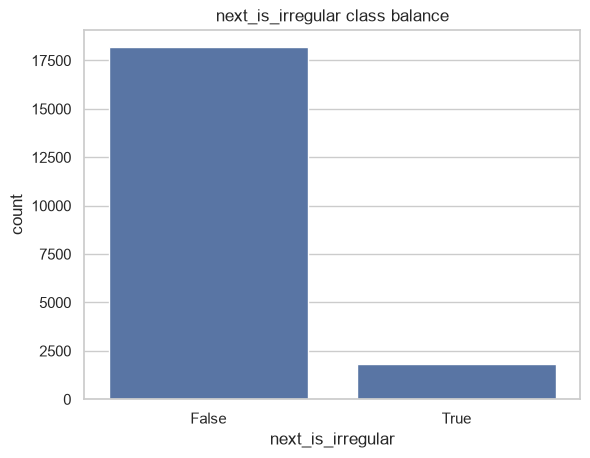

In [3]:
counts = df[TARGET_CLF].value_counts()
print(counts)
print("positive rate:", round(counts[True] / len(df), 4))
ax = sns.countplot(x=df[TARGET_CLF]); ax.set_title("next_is_irregular class balance")
plt.savefig(FIGURES_DIR / "eda_class_balance.png", dpi=150); plt.show()


## Correlation matrix (prevN_* and targets)

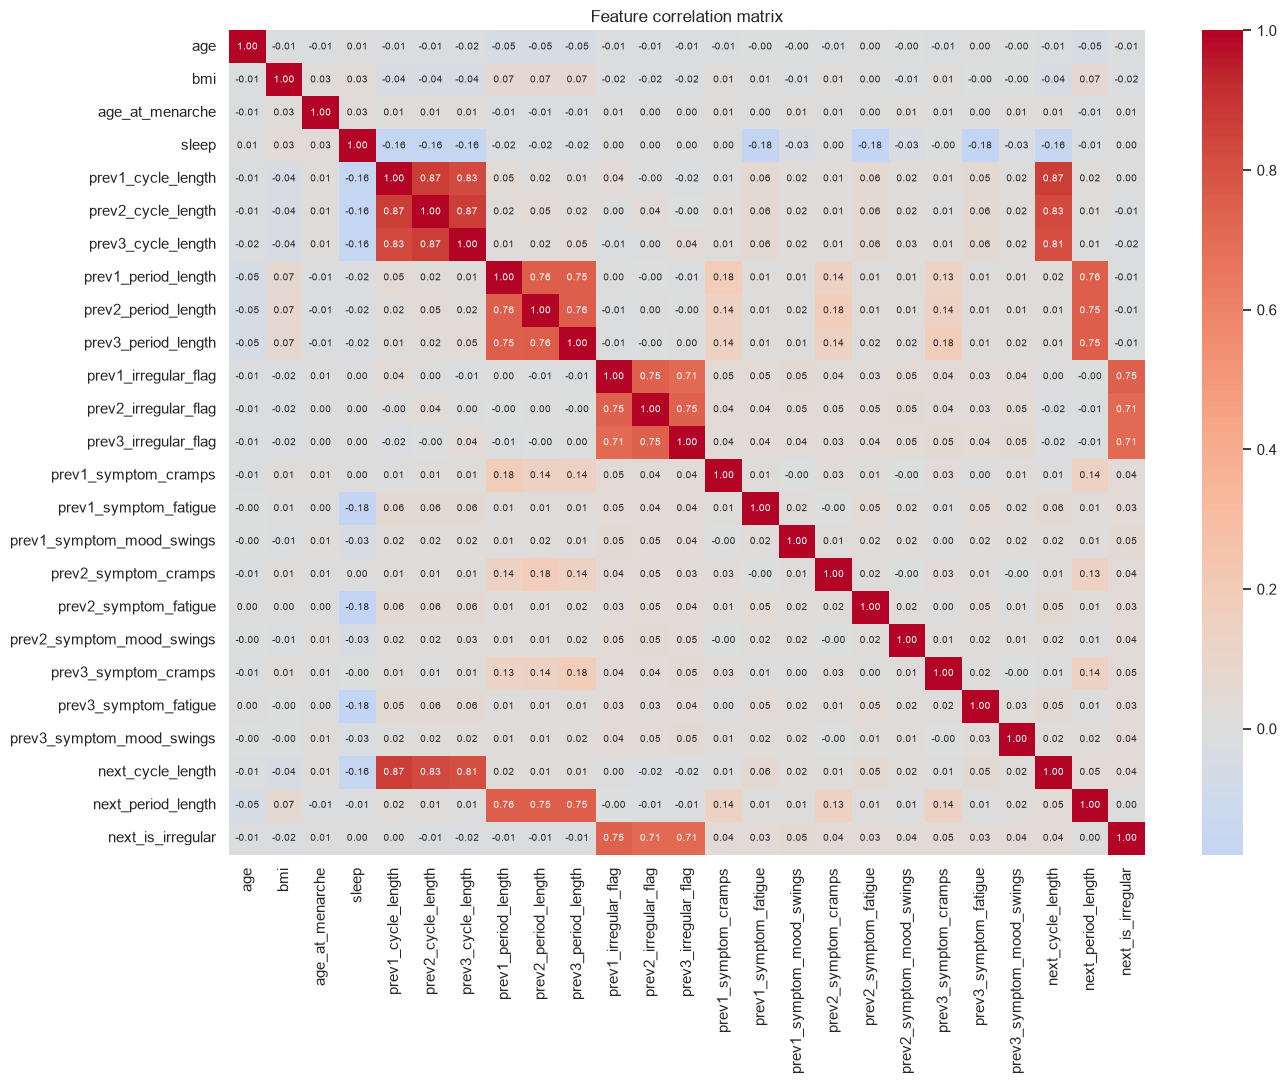

In [4]:
cols = [c for c in df.columns if c.startswith(("prev1_", "prev2_", "prev3_", "next_"))
        or c in ("age", "bmi", "sleep", "age_at_menarche")]
corr = df[cols].corr(numeric_only=True)
plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7})
plt.title("Feature correlation matrix")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "eda_correlation_matrix.png", dpi=150); plt.show()


## Categoricals vs targets

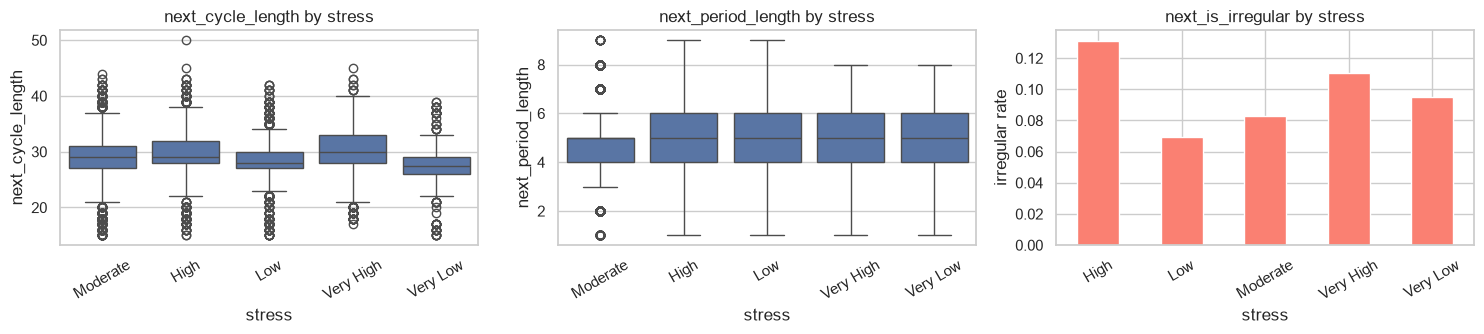

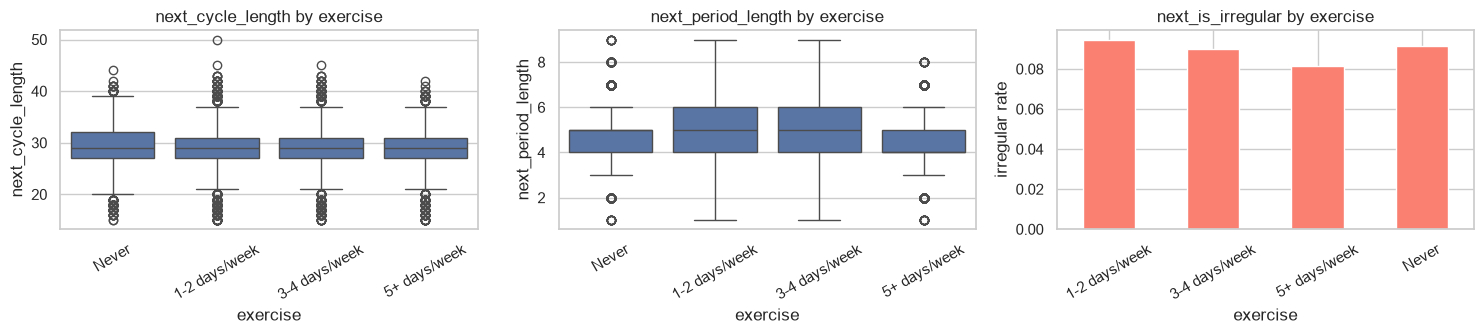

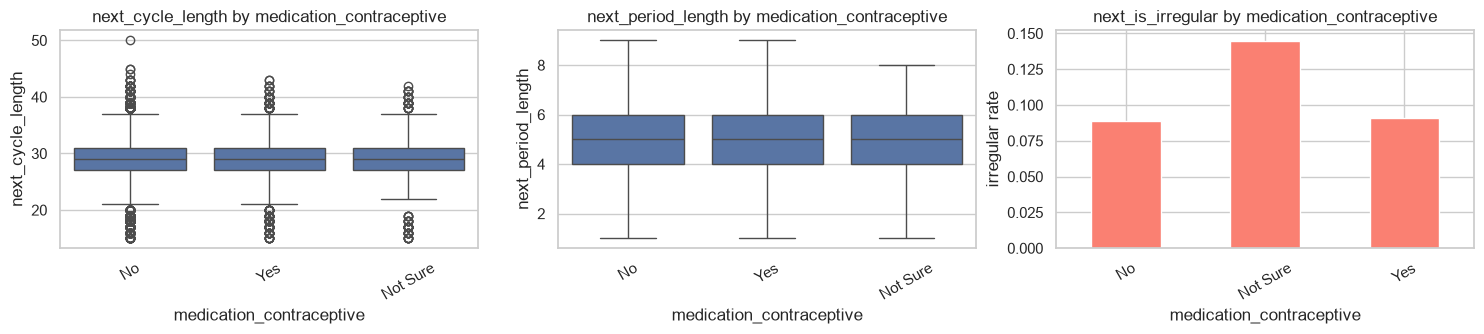

In [5]:
for cat in ["stress", "exercise", "medication_contraceptive"]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    for ax, t in zip(axes, TARGETS_REG + [TARGET_CLF]):
        if t == TARGET_CLF:
            df.groupby(cat)[t].mean().sort_index().plot(kind="bar", ax=ax, color="salmon")
            ax.set_ylabel("irregular rate")
        else:
            sns.boxplot(data=df, x=cat, y=t, ax=ax)
        ax.set_title(f"{t} by {cat}"); ax.tick_params(axis="x", rotation=30)
    plt.tight_layout(); plt.savefig(FIGURES_DIR / f"eda_{cat}_vs_targets.png", dpi=150); plt.show()


## Added diagnostics — missingness, near-duplicate profiles, full correlation heatmap

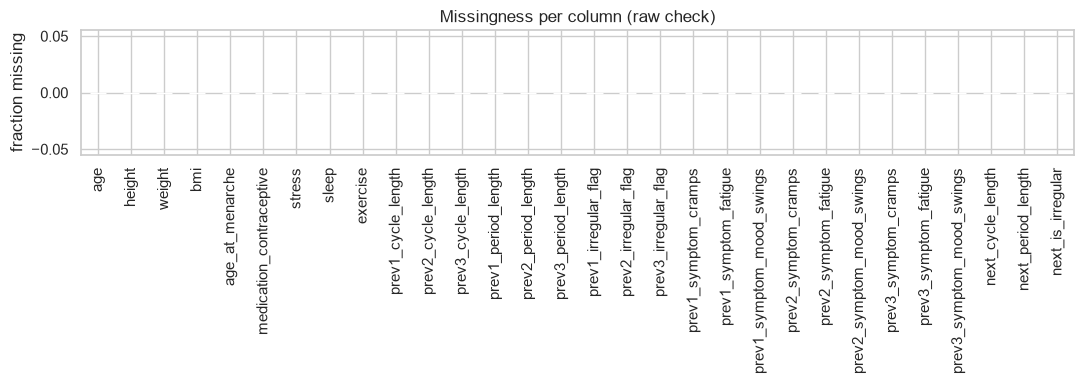

columns with any missing values: 0 | total NaN: 0


In [2]:
df = pd.read_csv(CLEANED_CSV)
miss = df.isna().mean().sort_values(ascending=False)
plt.figure(figsize=(11, 4))
miss.plot(kind="bar", color="steelblue")
plt.ylabel("fraction missing")
plt.title("Missingness per column (raw check)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "eda_missingness.png", dpi=150); plt.show()
print("columns with any missing values:", int((miss > 0).sum()), "| total NaN:", int(df.isna().sum().sum()))


rows sharing an identical static profile: 7417 / 20000 (37.1%) across 3235 groups | max group size: 7


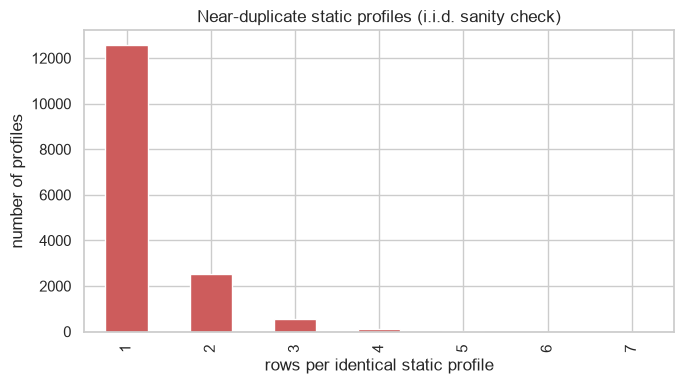

In [3]:
static_cols = ["age", "height", "weight", "bmi", "age_at_menarche",
               "medication_contraceptive", "stress", "sleep", "exercise"]
grp = df.groupby(static_cols).size()
dup_rows = int(grp[grp >= 2].sum())
print(f"rows sharing an identical static profile: {dup_rows} / {len(df)} "
      f"({dup_rows / len(df):.1%}) across {len(grp[grp >= 2])} groups | max group size: {int(grp.max())}")
plt.figure(figsize=(7, 4))
grp.value_counts().sort_index().plot(kind="bar", color="indianred")
plt.xlabel("rows per identical static profile"); plt.ylabel("number of profiles")
plt.title("Near-duplicate static profiles (i.i.d. sanity check)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "eda_near_duplicates.png", dpi=150); plt.show()


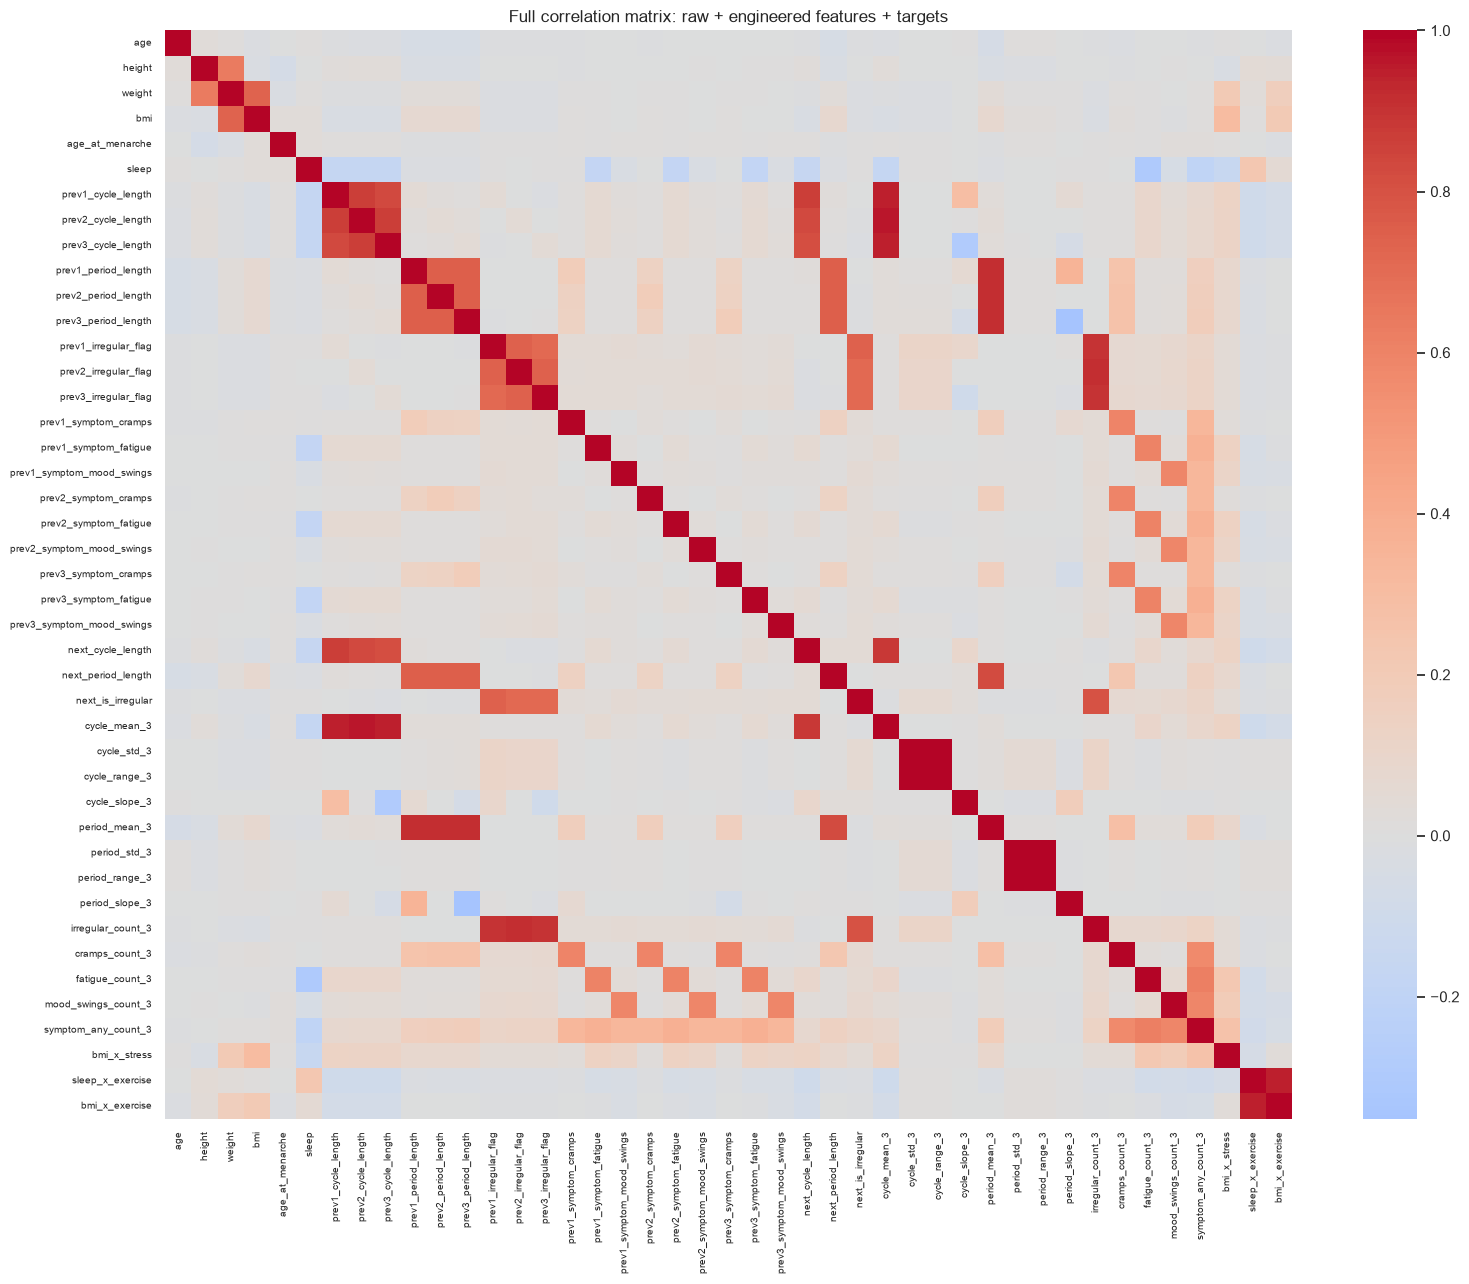

top-5 |corr| with next_cycle_length:
cycle_mean_3          0.879
prev1_cycle_length    0.867
prev2_cycle_length    0.826
prev3_cycle_length    0.813
sleep                -0.159 

top-5 |corr| with next_period_length:
period_mean_3          0.823
prev1_period_length    0.755
prev3_period_length    0.751
prev2_period_length    0.751
cramps_count_3         0.230 

top-5 |corr| with next_is_irregular:
irregular_count_3       0.797
prev1_irregular_flag    0.746
prev2_irregular_flag    0.714
prev3_irregular_flag    0.711
symptom_any_count_3     0.109 



In [4]:
eng = pd.read_csv(ENGINEERED_CSV)
num_cols = eng.select_dtypes(include=[np.number, bool]).columns
corr = eng[num_cols].corr()
plt.figure(figsize=(16, 13))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False,
            xticklabels=True, yticklabels=True)
plt.xticks(fontsize=7); plt.yticks(fontsize=7)
plt.title("Full correlation matrix: raw + engineered features + targets")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "eda_correlation_full.png", dpi=150); plt.show()
for t in TARGETS_REG + [TARGET_CLF]:
    s = corr[t].drop(index=[t]).sort_values(key=np.abs, ascending=False)[:5]
    print(f"top-5 |corr| with {t}:")
    print(s.round(3).to_string(), "\n")
